In [673]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sklearn.model_selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import ta
import warnings
warnings.filterwarnings('ignore')

# ===== LOAD DATA =====
df = pd.read_csv("NVDA.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(df.info())
print(f"Data shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}\n")



<class 'pandas.DataFrame'>
RangeIndex: 6558 entries, 0 to 6557
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6558 non-null   datetime64[us]
 1   Adj Close  6558 non-null   float64       
 2   Close      6558 non-null   float64       
 3   High       6558 non-null   float64       
 4   Low        6558 non-null   float64       
 5   Open       6558 non-null   float64       
 6   Volume     6558 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 358.8 KB
None
Data shape: (6558, 7)
Date range: 1999-01-22 00:00:00 to 2025-02-14 00:00:00



ROC 30-Day Statistics:
0     8.569811
1     1.436682
2     8.098636
3     3.748818
4     2.195728
5    11.843464
6     6.129055
7    15.733057
8    14.726053
9     9.091347
Name: roc_30d, dtype: float64

First 20 ROC values:
0      8.569811
1      1.436682
2      8.098636
3      3.748818
4      2.195728
5     11.843464
6      6.129055
7     15.733057
8     14.726053
9      9.091347
10     2.839443
11     0.000000
12     3.401165
13     5.840432
14     6.012747
15     3.292729
16    -5.952001
17     6.288895
18     1.547940
19    -4.791868
Name: roc_30d, dtype: float64


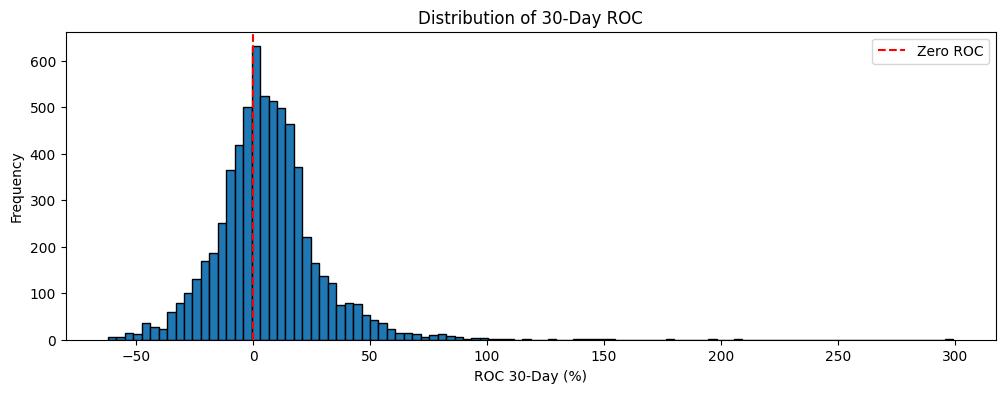


Target Value Counts:
target
1    4026
0    2532
Name: count, dtype: int64

Target Distribution (%):
target
1    61.390668
0    38.609332
Name: proportion, dtype: float64

Targetwith NaNs count:
Total rows: 6558
NaN in target: 0
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    0
12    1
13    1
14    1
15    1
16    0
17    1
18    1
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
50    1
51    0
52    0
53    0
54    0
55    0
56    0
57    0
58    0
59    0
Name: target, dtype: int64
0    1999-01-22
1    1999-01-25
2    1999-01-26
3    1999-01-27
4    1999-01-28
5    1999-01-29
6    1999-02-01
7    1999-02-02
8    1999-02-03
9    1999-02-04
10   1999-02-05
11   1999-02-08
12   1999-02-09
13   1999-02-10
14   1999-02-11
15   1999-02-12
16   199

In [674]:
# ===== CALCULATE ROC (RATE OF CHANGE) WITH 30-DAY HORIZON =====
horizon = 30

# ROC calculates: ((Price_today - Price_n_periods_ago) / Price_n_periods_ago) * 100
# We want forward ROC: ((Price_future - Price_today) / Price_today) * 100
df["roc_30d"] = ((df["Adj Close"].shift(-horizon) - df["Adj Close"]) / df["Adj Close"]) * 100

print("ROC 30-Day Statistics:")
print(df["roc_30d"].head(10))
print(f"\nFirst 20 ROC values:")
print(df["roc_30d"].head(20))

# Visualize ROC distribution
plt.figure(figsize=(12, 4))
plt.hist(df["roc_30d"].dropna(), bins=100, edgecolor='black')
plt.xlabel("ROC 30-Day (%)")
plt.ylabel("Frequency")
plt.title("Distribution of 30-Day ROC")
plt.axvline(x=0, color='red', linestyle='--', label='Zero ROC')
plt.legend()
plt.show()

# ===== CREATE TARGET COLUMN: 0 for negative/zero, 1 for positive =====
threshold = 0.02
df["target"] = np.where(df["roc_30d"] > threshold, 1, 0)

print("\nTarget Value Counts:")
print(df["target"].value_counts())
print(f"\nTarget Distribution (%):")
print(df["target"].value_counts(normalize=True) * 100)

print(f"\nTargetwith NaNs count:")
print(f"Total rows: {len(df)}")
print(f"NaN in target: {df['target'].isna().sum()}")
print(df["target"].head(60))
print(df["Date"].head(20))
df = df.iloc[:-horizon]  # Remove last 'horizon' rows with NaN targets

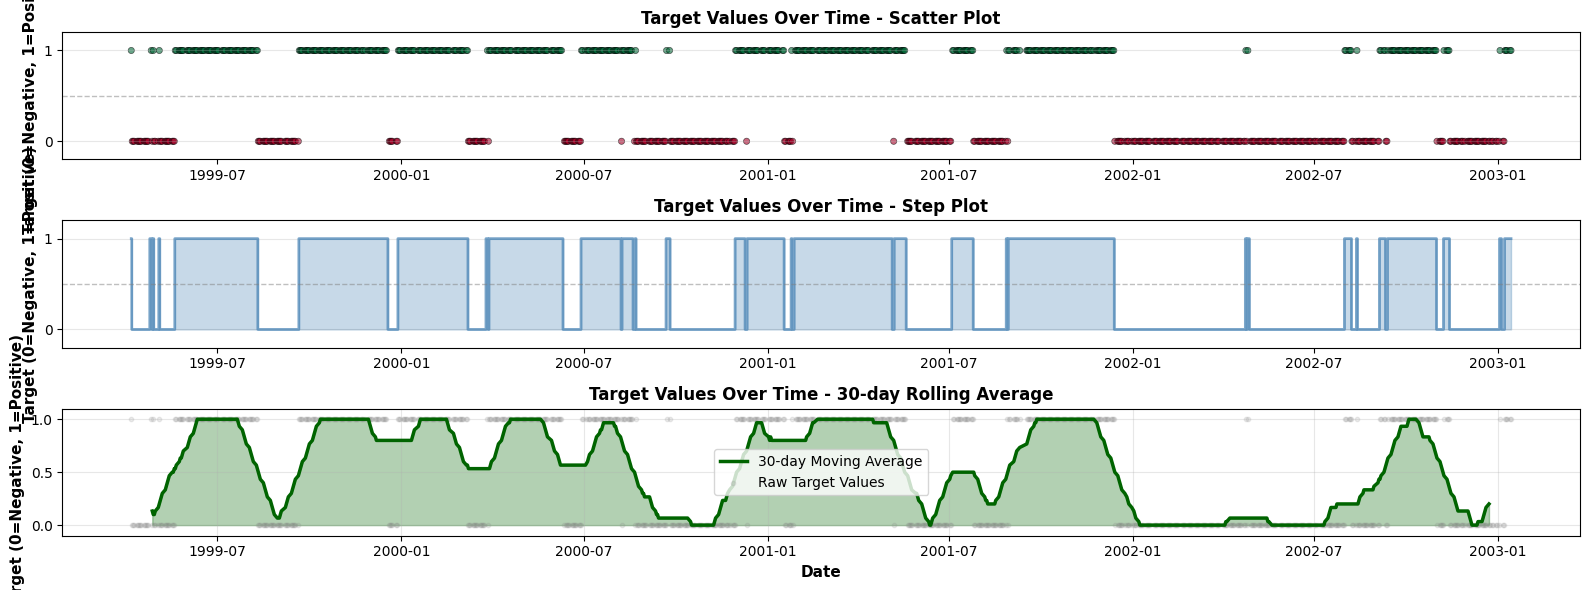

In [675]:
def plot_target_over_time(df, figsize=(16, 6)):
    """
    Visualize target values (0s and 1s) over time with multiple visualization styles.
    
    Parameters:
    -----------
    df : pandas DataFrame
        Must contain 'Date' and 'target' columns
    figsize : tuple
        Figure size for plots
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    
    fig, axes = plt.subplots(3, 1, figsize=figsize)
    
    # Plot 1: Scatter plot (clearest for individual values)
    axes[0].scatter(df['Date'], df['target'], alpha=0.6, s=20, c=df['target'], 
                    cmap='RdYlGn', edgecolors='black', linewidth=0.5)
    axes[0].set_ylabel('Target (0=Negative, 1=Positive)', fontsize=11, fontweight='bold')
    axes[0].set_title('Target Values Over Time - Scatter Plot', fontsize=12, fontweight='bold')
    axes[0].set_ylim([-0.2, 1.2])
    axes[0].set_yticks([0, 1])
    axes[0].grid(alpha=0.3, axis='y')
    axes[0].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Plot 2: Step plot (shows transitions clearly)
    axes[1].step(df['Date'], df['target'], where='mid', linewidth=2, alpha=0.7, color='steelblue')
    axes[1].fill_between(df['Date'], df['target'], step='mid', alpha=0.3, color='steelblue')
    axes[1].set_ylabel('Target (0=Negative, 1=Positive)', fontsize=11, fontweight='bold')
    axes[1].set_title('Target Values Over Time - Step Plot', fontsize=12, fontweight='bold')
    axes[1].set_ylim([-0.2, 1.2])
    axes[1].set_yticks([0, 1])
    axes[1].grid(alpha=0.3, axis='y')
    axes[1].axhline(y=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    # Plot 3: Rolling average (smoothed trend)
    rolling_avg = df['target'].rolling(window=30, center=True).mean()
    axes[2].plot(df['Date'], rolling_avg, linewidth=2.5, color='darkgreen', label='30-day Moving Average')
    axes[2].fill_between(df['Date'], rolling_avg, alpha=0.3, color='darkgreen')
    axes[2].scatter(df['Date'], df['target'], alpha=0.15, s=10, color='gray', label='Raw Target Values')
    axes[2].set_xlabel('Date', fontsize=11, fontweight='bold')
    axes[2].set_ylabel('Target (0=Negative, 1=Positive)', fontsize=11, fontweight='bold')
    axes[2].set_title('Target Values Over Time - 30-day Rolling Average', fontsize=12, fontweight='bold')
    axes[2].set_ylim([-0.1, 1.1])
    axes[2].set_yticks([0, 0.5, 1])
    axes[2].grid(alpha=0.3)
    axes[2].legend(loc='best')
    
    plt.tight_layout()
    plt.show()

# Usage in your notebook:
df_good = df[50:1000]  # Adjust this range as needed to focus on a specific time period
plot_target_over_time(df_good)


CONSECUTIVE 1s (POSITIVE RETURNS)
Total streaks of 1s: 253
Streak lengths distribution:
1      84
2      24
3      14
4      13
5       6
6       9
7      10
8       5
9       5
10      1
11      7
12      3
13      1
14      1
15      3
16      3
17      2
20      1
23      1
24      2
25      3
26      1
27      1
28      2
29      1
30      1
31      2
32      3
33      2
34      2
35      2
38      2
39      3
40      1
42      1
43      2
44      1
46      2
48      1
50      1
51      1
52      1
53      2
54      1
57      5
63      1
68      1
69      2
70      1
75      1
77      1
111     1
117     1
121     1
127     1
129     1
162     1
187     1
Name: count, dtype: int64

Min streak: 1, Max streak: 187, Avg: 15.91

CONSECUTIVE 0s (NEGATIVE RETURNS)
Total streaks of 0s: 252
Streak lengths distribution:
1     92
2     27
3     25
4     16
5      4
6      8
7      4
8      6
9      5
10     2
11     2
13     8
14     5
15     2
16     1
18     3
20     3
21     6
23     3
26

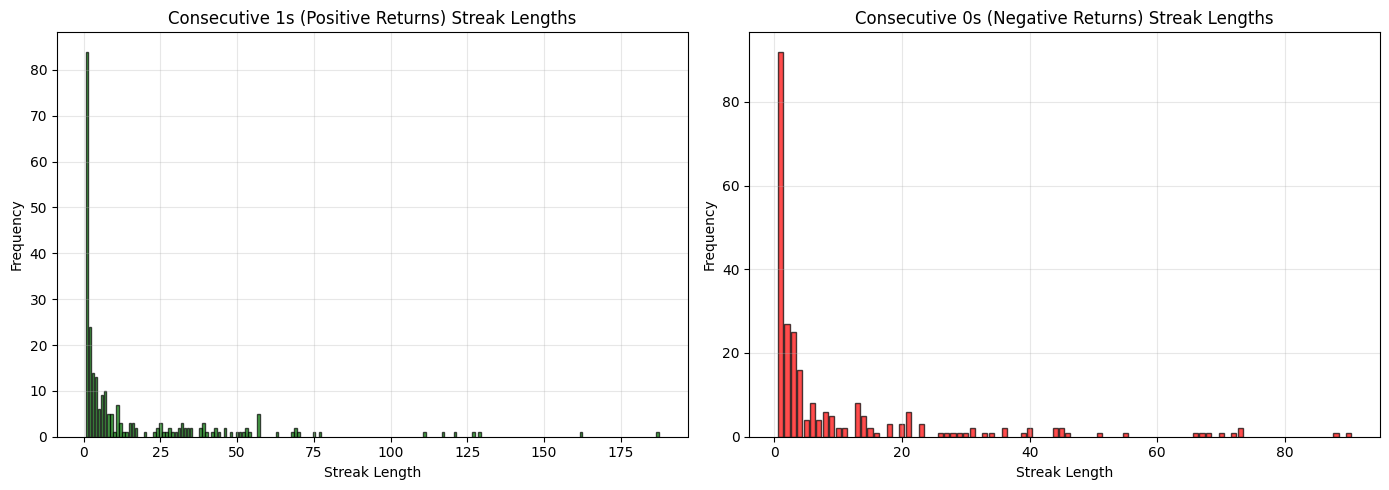

In [676]:
# ===== ANALYZE CONSECUTIVE 1s AND 0s =====

def analyze_streaks(series):
    """
    Analyze consecutive occurrences of same value in a series.
    Returns streak lengths and their frequencies.
    """
    # Remove NaN values
    clean_series = series.dropna().reset_index(drop=True)
    
    streaks_1 = []
    streaks_0 = []
    
    current_value = clean_series.iloc[0]
    current_streak = 1
    
    for i in range(1, len(clean_series)):
        if clean_series.iloc[i] == current_value:
            current_streak += 1
        else:
            # Streak ended
            if current_value == 1:
                streaks_1.append(current_streak)
            else:
                streaks_0.append(current_streak)
            
            # Start new streak
            current_value = clean_series.iloc[i]
            current_streak = 1
    
    # Don't forget last streak
    if current_value == 1:
        streaks_1.append(current_streak)
    else:
        streaks_0.append(current_streak)
    
    return streaks_1, streaks_0

# Get streaks
streaks_1, streaks_0 = analyze_streaks(df["target"])

print("=" * 50)
print("CONSECUTIVE 1s (POSITIVE RETURNS)")
print("=" * 50)
print(f"Total streaks of 1s: {len(streaks_1)}")
print(f"Streak lengths distribution:")
streak_1_counts = pd.Series(streaks_1).value_counts().sort_index()
print(streak_1_counts)
print(f"\nMin streak: {min(streaks_1)}, Max streak: {max(streaks_1)}, Avg: {np.mean(streaks_1):.2f}")

print("\n" + "=" * 50)
print("CONSECUTIVE 0s (NEGATIVE RETURNS)")
print("=" * 50)
print(f"Total streaks of 0s: {len(streaks_0)}")
print(f"Streak lengths distribution:")
streak_0_counts = pd.Series(streaks_0).value_counts().sort_index()
print(streak_0_counts)
print(f"\nMin streak: {min(streaks_0)}, Max streak: {max(streaks_0)}, Avg: {np.mean(streaks_0):.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(streak_1_counts.index, streak_1_counts.values, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel("Streak Length")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Consecutive 1s (Positive Returns) Streak Lengths")
axes[0].grid(alpha=0.3)

axes[1].bar(streak_0_counts.index, streak_0_counts.values, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel("Streak Length")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Consecutive 0s (Negative Returns) Streak Lengths")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

WEIGHTED ANALYSIS (Days Contribution)

1s (Positive): 4026 total days across 253 streaks
0s (Negative): 2502 total days across 252 streaks
Total days: 6528

1s (POSITIVE RETURNS) - Contribution Summary
 Streak Length  Frequency  Total Days  Percentage
            57          5         285        7.08
           187          1         187        4.64
           162          1         162        4.02
            69          2         138        3.43
           129          1         129        3.20
           127          1         127        3.15
           121          1         121        3.01
            39          3         117        2.91
           117          1         117        2.91
           111          1         111        2.76
            53          2         106        2.63
            32          3          96        2.38
            46          2          92        2.29
            43          2          86        2.14
             1         84          84        2.0

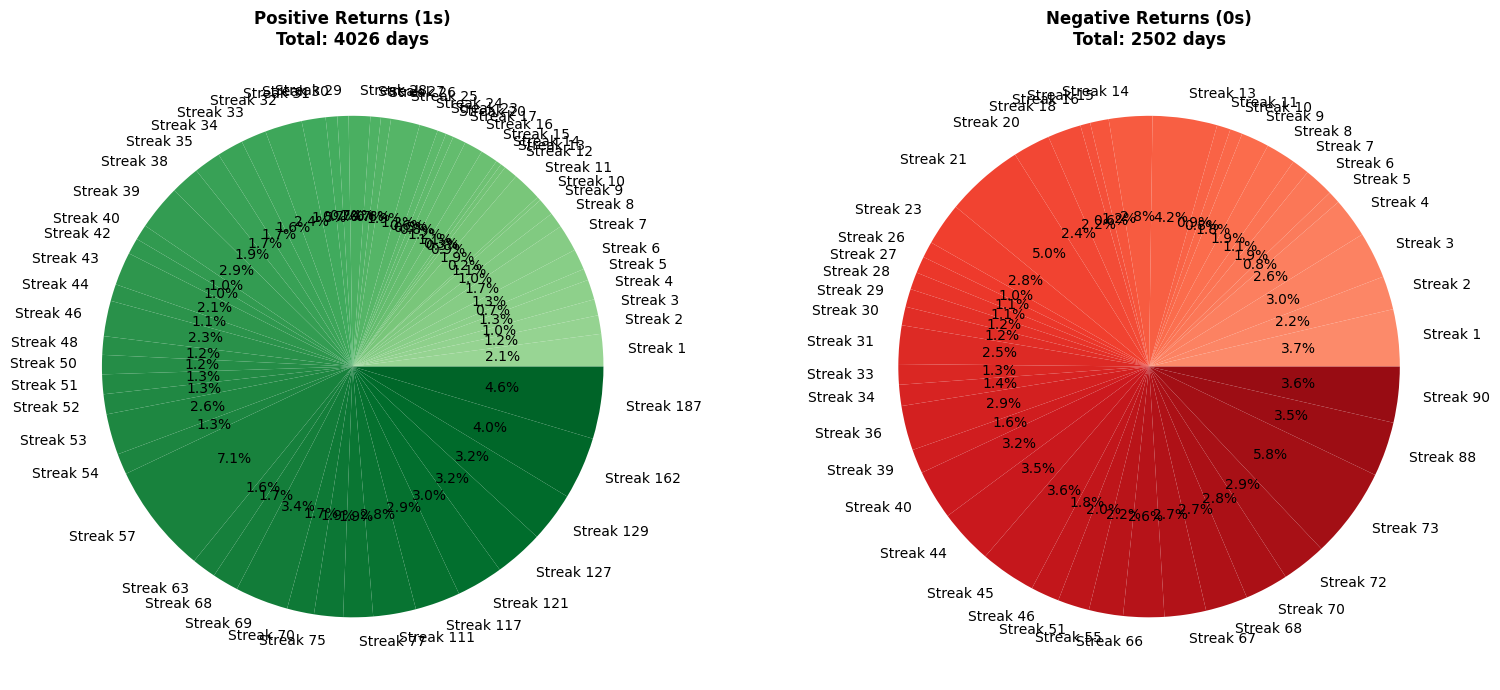

In [677]:
# ===== CREATE WEIGHTED PIE CHARTS =====

# Calculate total days in each streak type
streak_1_total_days = sum([length * count for length, count in streak_1_counts.items()])
streak_0_total_days = sum([length * count for length, count in streak_0_counts.items()])

print("=" * 70)
print("WEIGHTED ANALYSIS (Days Contribution)")
print("=" * 70)
print(f"\n1s (Positive): {streak_1_total_days} total days across {len(streaks_1)} streaks")
print(f"0s (Negative): {streak_0_total_days} total days across {len(streaks_0)} streaks")
print(f"Total days: {streak_1_total_days + streak_0_total_days}")

# Create weighted contribution for each streak length
streak_1_weighted = streak_1_counts * streak_1_counts.index
streak_0_weighted = streak_0_counts * streak_0_counts.index

# Create summary tables
summary_1 = pd.DataFrame({
    'Streak Length': streak_1_weighted.index,
    'Frequency': streak_1_counts.values,
    'Total Days': streak_1_weighted.values,
    'Percentage': (streak_1_weighted.values / streak_1_total_days * 100).round(2)
}).sort_values('Total Days', ascending=False).reset_index(drop=True)

summary_0 = pd.DataFrame({
    'Streak Length': streak_0_weighted.index,
    'Frequency': streak_0_counts.values,
    'Total Days': streak_0_weighted.values,
    'Percentage': (streak_0_weighted.values / streak_0_total_days * 100).round(2)
}).sort_values('Total Days', ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("1s (POSITIVE RETURNS) - Contribution Summary")
print("=" * 70)
print(summary_1.to_string(index=False))

print("\n" + "=" * 70)
print("0s (NEGATIVE RETURNS) - Contribution Summary")
print("=" * 70)
print(summary_0.to_string(index=False))

# Create pie charts
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].pie(streak_1_weighted, labels=[f"Streak {x}" for x in streak_1_weighted.index], 
            autopct='%1.1f%%', colors=plt.cm.Greens(np.linspace(0.4, 0.9, len(streak_1_weighted))),
            textprops={'fontsize': 10})
axes[0].set_title(f"Positive Returns (1s)\nTotal: {streak_1_total_days} days", fontsize=12, fontweight='bold')

axes[1].pie(streak_0_weighted, labels=[f"Streak {x}" for x in streak_0_weighted.index], 
            autopct='%1.1f%%', colors=plt.cm.Reds(np.linspace(0.4, 0.9, len(streak_0_weighted))),
            textprops={'fontsize': 10})
axes[1].set_title(f"Negative Returns (0s)\nTotal: {streak_0_total_days} days", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [678]:
# ===== CALCULATE WEIGHTED AVERAGE STREAK LENGTH (CORRECTED) =====

# Simple average - just mean of all streak lengths
simple_avg_streak_1 = np.mean(streaks_1)
simple_avg_streak_0 = np.mean(streaks_0)

# Weighted average - weighted by the percentage contribution
# Each streak length should be weighted by how much it contributes to total days
weighted_avg_streak_1 = (summary_1['Streak Length'] * summary_1['Percentage'] / 100).sum()
weighted_avg_streak_0 = (summary_0['Streak Length'] * summary_0['Percentage'] / 100).sum()

print("=" * 70)
print("AVERAGE STREAK LENGTH ANALYSIS")
print("=" * 70)

print(f"\n1s (POSITIVE RETURNS):")
print(f"  Simple Average Streak Length: {simple_avg_streak_1:.2f} days")
print(f"  Weighted Average Streak Length: {weighted_avg_streak_1:.2f} days")
print(f"  Difference: {weighted_avg_streak_1 - simple_avg_streak_1:.2f} days")
print(f"  Total Streaks: {len(streaks_1)}")
print(f"  Total Days: {streak_1_total_days}")

print(f"\n0s (NEGATIVE RETURNS):")
print(f"  Simple Average Streak Length: {simple_avg_streak_0:.2f} days")
print(f"  Weighted Average Streak Length: {weighted_avg_streak_0:.2f} days")
print(f"  Difference: {weighted_avg_streak_0 - simple_avg_streak_0:.2f} days")
print(f"  Total Streaks: {len(streaks_0)}")
print(f"  Total Days: {streak_0_total_days}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print("\nSimple Average: Mean length of all streaks (treats each streak equally)")
print("Weighted Average: Average weighted by % contribution to total days")
print("\nIf Weighted > Simple: Longer streaks dominate (more momentum)")
print("If Weighted = Simple: All streak lengths equally important")
print("If Weighted < Simple: Shorter streaks have more influence")

AVERAGE STREAK LENGTH ANALYSIS

1s (POSITIVE RETURNS):
  Simple Average Streak Length: 15.91 days
  Weighted Average Streak Length: 62.41 days
  Difference: 46.50 days
  Total Streaks: 253
  Total Days: 4026

0s (NEGATIVE RETURNS):
  Simple Average Streak Length: 9.93 days
  Weighted Average Streak Length: 37.23 days
  Difference: 27.30 days
  Total Streaks: 252
  Total Days: 2502

INTERPRETATION

Simple Average: Mean length of all streaks (treats each streak equally)
Weighted Average: Average weighted by % contribution to total days

If Weighted > Simple: Longer streaks dominate (more momentum)
If Weighted = Simple: All streak lengths equally important
If Weighted < Simple: Shorter streaks have more influence


YEARLY DISTRIBUTION OF TARGET VALUES
target    0    1
Year            
1999     95  144
2000     97  155
2001     73  175
2002    201   51
2003     76  176
2004    134  118
2005     58  194
2006     81  170
2007    103  148
2008    161   92
2009     84  168
2010    112  140
2011    148  104
2012    144  106
2013     56  196
2014     86  166
2015    108  144
2016      6  246
2017     64  187
2018    132  119
2019     56  196
2020     62  191
2021     84  168
2022    145  106
2023     39  211
2024     97  155

Yearly Percentages:
target      0      1
Year                
1999    39.75  60.25
2000    38.49  61.51
2001    29.44  70.56
2002    79.76  20.24
2003    30.16  69.84
2004    53.17  46.83
2005    23.02  76.98
2006    32.27  67.73
2007    41.04  58.96
2008    63.64  36.36
2009    33.33  66.67
2010    44.44  55.56
2011    58.73  41.27
2012    57.60  42.40
2013    22.22  77.78
2014    34.13  65.87
2015    42.86  57.14
2016     2.38  97.62
2017    25.50  74.50
2018    52.59  47.41
2019

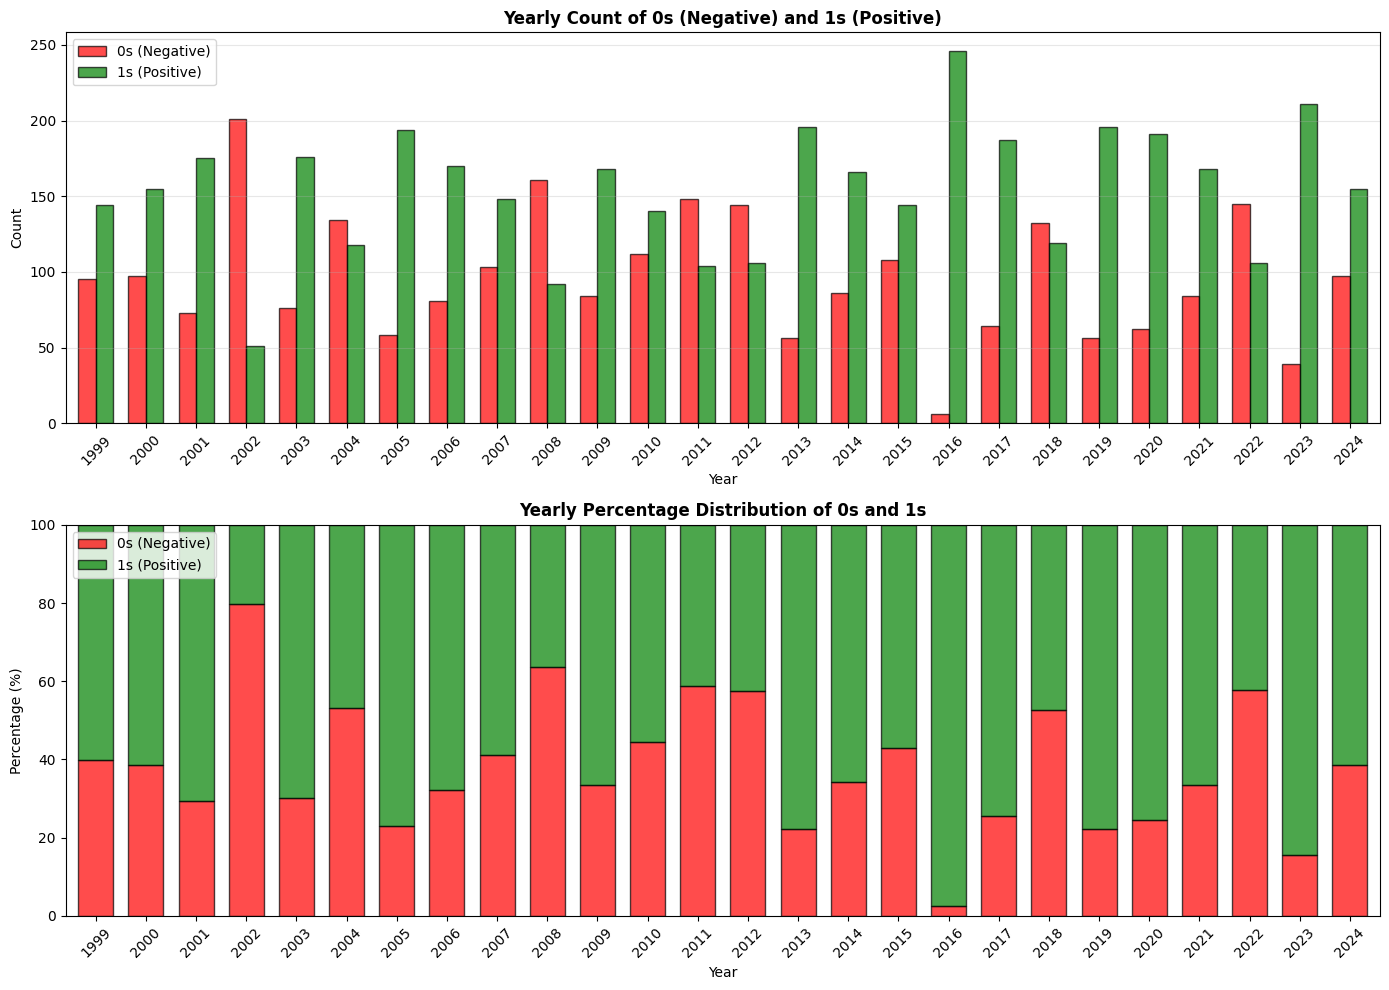


YEARLY SUMMARY

1999:
  Total days: 239
  Positive (1s): 144 days (60.3%)
  Negative (0s): 95 days (39.7%)

2000:
  Total days: 252
  Positive (1s): 155 days (61.5%)
  Negative (0s): 97 days (38.5%)

2001:
  Total days: 248
  Positive (1s): 175 days (70.6%)
  Negative (0s): 73 days (29.4%)

2002:
  Total days: 252
  Positive (1s): 51 days (20.2%)
  Negative (0s): 201 days (79.8%)

2003:
  Total days: 252
  Positive (1s): 176 days (69.8%)
  Negative (0s): 76 days (30.2%)

2004:
  Total days: 252
  Positive (1s): 118 days (46.8%)
  Negative (0s): 134 days (53.2%)

2005:
  Total days: 252
  Positive (1s): 194 days (77.0%)
  Negative (0s): 58 days (23.0%)

2006:
  Total days: 251
  Positive (1s): 170 days (67.7%)
  Negative (0s): 81 days (32.3%)

2007:
  Total days: 251
  Positive (1s): 148 days (59.0%)
  Negative (0s): 103 days (41.0%)

2008:
  Total days: 253
  Positive (1s): 92 days (36.4%)
  Negative (0s): 161 days (63.6%)

2009:
  Total days: 252
  Positive (1s): 168 days (66.7%)
  N

In [679]:
# ===== YEARLY DISTRIBUTION OF 0s AND 1s =====

# Add year column
df["Year"] = df["Date"].dt.year

# Count 0s and 1s by year
yearly_counts = df.groupby("Year")["target"].value_counts().unstack(fill_value=0)

print("=" * 70)
print("YEARLY DISTRIBUTION OF TARGET VALUES")
print("=" * 70)
print(yearly_counts)
print()

# Calculate percentages
yearly_pct = df.groupby("Year")["target"].value_counts(normalize=True).unstack(fill_value=0) * 100
print("Yearly Percentages:")
print(yearly_pct.round(2))
print()

# Create bar plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Stacked bar chart
yearly_counts.plot(kind='bar', stacked=False, ax=axes[0], color=['red', 'green'], 
                   alpha=0.7, edgecolor='black', width=0.7)
axes[0].set_title('Yearly Count of 0s (Negative) and 1s (Positive)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].legend(['0s (Negative)', '1s (Positive)'], loc='upper left')
axes[0].grid(alpha=0.3, axis='y')
axes[0].set_xticklabels(yearly_counts.index, rotation=45)

# Plot 2: Percentage stacked bar chart
yearly_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['red', 'green'], 
                alpha=0.7, edgecolor='black', width=0.7)
axes[1].set_title('Yearly Percentage Distribution of 0s and 1s', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(['0s (Negative)', '1s (Positive)'], loc='upper left')
axes[1].set_xticklabels(yearly_counts.index, rotation=45)
axes[1].set_ylim([0, 100])

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 70)
print("YEARLY SUMMARY")
print("=" * 70)
for year in yearly_counts.index:
    total = yearly_counts.loc[year].sum()
    pos = yearly_counts.loc[year, 1] if 1 in yearly_counts.columns else 0
    neg = yearly_counts.loc[year, 0] if 0 in yearly_counts.columns else 0
    pos_pct = (pos / total * 100) if total > 0 else 0
    neg_pct = (neg / total * 100) if total > 0 else 0
    
    print(f"\n{year}:")
    print(f"  Total days: {total}")
    print(f"  Positive (1s): {pos} days ({pos_pct:.1f}%)")
    print(f"  Negative (0s): {neg} days ({neg_pct:.1f}%)")

In [680]:
# ===== CREATE TECHNICAL INDICATORS =====

print("\n" + "=" * 80)
print("CREATING TECHNICAL INDICATORS")
print("=" * 80)

# ===== FEATURE 1: EMA RATIO (20/50) - TREND =====
df["ema_20"] = ta.trend.EMAIndicator(df["Adj Close"], window=20).ema_indicator()
df["ema_50"] = ta.trend.EMAIndicator(df["Adj Close"], window=50).ema_indicator()
df["ema_ratio_20_50"] = df["ema_20"] / df["ema_50"]

# ===== FEATURE 2: PRICE TO EMA20 RATIO =====
df["price_to_ema20"] = df["Adj Close"] / df["ema_20"]

# ===== FEATURE 3: RSI (14) - MOMENTUM =====
df["rsi_14"] = ta.momentum.RSIIndicator(df["Adj Close"], window=14).rsi()

# ===== FEATURE 4: STOCHASTIC %K =====
stoch = ta.momentum.StochasticOscillator(df["High"], df["Low"], df["Adj Close"], 
                                        window=14, smooth_window=3)
df["stoch_k"] = stoch.stoch()

# ===== FEATURE 5: ROC (10) - RATE OF CHANGE =====
df["roc_10"] = ta.momentum.ROCIndicator(df["Adj Close"], window=10).roc()

# ===== FEATURE 6: VOLATILITY (20-DAY) =====
df["volatility_20"] = df["Adj Close"].pct_change().rolling(window=20).std() * 100

# ===== FEATURE 7: ATR RATIO =====
atr = ta.volatility.AverageTrueRange(df["High"], df["Low"], df["Adj Close"], window=14)
df["atr"] = atr.average_true_range()
df["atr_ratio"] = (df["atr"] / df["Adj Close"]) * 100

# ===== FEATURE 8: OBV CHANGE =====
obv = ta.volume.OnBalanceVolumeIndicator(df["Adj Close"], df["Volume"])
df["obv"] = obv.on_balance_volume()
df["obv_change"] = df["obv"].pct_change() * 100

# ===== FEATURE 9: VOLUME Z-SCORE =====
df["volume_mean"] = df["Volume"].rolling(window=20).mean()
df["volume_std"] = df["Volume"].rolling(window=20).std()
df["volume_zscore"] = (df["Volume"] - df["volume_mean"]) / (df["volume_std"] + 1)
df["volume_zscore"] = df["volume_zscore"].clip(-5, 5)

# ===== FEATURE 10: BOLLINGER BAND POSITION =====
bb = ta.volatility.BollingerBands(df["Adj Close"], window=20, window_dev=2)
df["bb_high"] = bb.bollinger_hband()
df["bb_low"] = bb.bollinger_lband()
df["bb_position"] = (df["Adj Close"] - df["bb_low"]) / (df["bb_high"] - df["bb_low"])
df["bb_position"] = df["bb_position"].clip(0, 1)

# ===== FEATURE 11: RANGE RATIO (High-Low / Close) =====
df["range_ratio"] = (df["High"] - df["Low"]) / df["Adj Close"] * 100

# ===== FEATURE 12: CLOSE TO HIGH RATIO =====
df["close_to_high"] = df["Adj Close"] / df["High"]

# ===== FEATURE 13: 1-DAY RETURN =====
df["return_1d"] = df["Adj Close"].pct_change() * 100

# ===== FEATURE 14: 5-DAY RETURN =====
df["return_5d"] = (df["Adj Close"] / df["Adj Close"].shift(5) - 1) * 100

# ===== FEATURE 15: 10-DAY RETURN SKEWNESS =====
df["return_skew_10"] = df["Adj Close"].pct_change().rolling(window=10).skew() * 100

print("✓ All 15 technical indicators created!")
# =========================
# LOW-COLLINEARITY FEATURES ONLY
# =========================

# 1. Momentum Acceleration (new dimension: change of momentum)
df["momentum_acc"] = df["roc_10"] - df["roc_10"].shift(5)

# 2. Trend Consistency (behavioral feature, not price-based)
df["trend_consistency_10"] = (df["return_1d"] > 0).rolling(10).mean()

# 3. Volatility Regime (relative volatility, not absolute)
df["vol_regime"] = df["volatility_20"] / df["volatility_20"].rolling(100).mean()

# 4. Price Percentile (long-term context, NOT captured currently)
df["price_percentile_100"] = df["Adj Close"].rolling(100).rank(pct=True)

print("✅ Low-collinearity features added!")

# ===== FEATURES LIST =====
features = [
    "ema_ratio_20_50",
    "price_to_ema20",
    "rsi_14",
    "stoch_k",
    "roc_10",
    "volatility_20",
    "atr_ratio",
    "obv_change",
    "volume_zscore",
    "bb_position",
    "range_ratio",
    "close_to_high",
    "return_1d",
    "return_5d",
    "return_skew_10","momentum_acc",
    "trend_consistency_10",  "vol_regime",
    "price_percentile_100"
]

print(f"\n✓ Features list created with {len(features)} indicators")


CREATING TECHNICAL INDICATORS
✓ All 15 technical indicators created!
✅ Low-collinearity features added!

✓ Features list created with 19 indicators


In [681]:
df = df.dropna()
df.isna().sum()

Date                    0
Adj Close               0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0
roc_30d                 0
target                  0
Year                    0
ema_20                  0
ema_50                  0
ema_ratio_20_50         0
price_to_ema20          0
rsi_14                  0
stoch_k                 0
roc_10                  0
volatility_20           0
atr                     0
atr_ratio               0
obv                     0
obv_change              0
volume_mean             0
volume_std              0
volume_zscore           0
bb_high                 0
bb_low                  0
bb_position             0
range_ratio             0
close_to_high           0
return_1d               0
return_5d               0
return_skew_10          0
momentum_acc            0
trend_consistency_10    0
vol_regime              0
price_percentile_100    0
dtype: int64

In [682]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 6409 entries, 119 to 6527
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  6409 non-null   datetime64[us]
 1   Adj Close             6409 non-null   float64       
 2   Close                 6409 non-null   float64       
 3   High                  6409 non-null   float64       
 4   Low                   6409 non-null   float64       
 5   Open                  6409 non-null   float64       
 6   Volume                6409 non-null   int64         
 7   roc_30d               6409 non-null   float64       
 8   target                6409 non-null   int64         
 9   Year                  6409 non-null   int32         
 10  ema_20                6409 non-null   float64       
 11  ema_50                6409 non-null   float64       
 12  ema_ratio_20_50       6409 non-null   float64       
 13  price_to_ema20        6409 

In [683]:
selected_features = [
    "ema_ratio_20_50",
    "rsi_14",
    "stoch_k",
    "roc_10",
    "volatility_20",
    "bb_position",
    "volume_zscore",
    "obv_change",
    "return_5d","momentum_acc",
    "trend_consistency_10",  "vol_regime"
]

X = df[selected_features]
y = df["target"]
print(y.info())
print(y.value_counts())
print((X.index==y.index).all())

<class 'pandas.Series'>
RangeIndex: 6409 entries, 119 to 6527
Series name: target
Non-Null Count  Dtype
--------------  -----
6409 non-null   int64
dtypes: int64(1)
memory usage: 50.2 KB
None
target
1    3968
0    2441
Name: count, dtype: int64
True


In [684]:
target_corr = pd.concat([X, y], axis=1).corr()["target"].drop("target").sort_values(ascending=False)
print("\nCorrelation of features with target:")   
print(target_corr)                                                               


Correlation of features with target:
rsi_14                  0.074153
stoch_k                 0.067537
trend_consistency_10    0.056302
bb_position             0.054174
ema_ratio_20_50         0.054002
roc_10                  0.048485
return_5d               0.027845
vol_regime              0.008644
momentum_acc            0.006344
volume_zscore          -0.004811
obv_change             -0.005153
volatility_20          -0.028294
Name: target, dtype: float64


                      ema_ratio_20_50    rsi_14   stoch_k    roc_10  \
ema_ratio_20_50              1.000000  0.632516  0.249671  0.366214   
rsi_14                       0.632516  1.000000  0.620334  0.737517   
stoch_k                      0.249671  0.620334  1.000000  0.545458   
roc_10                       0.366214  0.737517  0.545458  1.000000   
volatility_20                0.183899  0.117919  0.176593  0.101435   
bb_position                  0.378845  0.887712  0.670154  0.751051   
volume_zscore                0.000441  0.023105  0.017734  0.050828   
obv_change                   0.009121  0.020149  0.023800  0.031289   
return_5d                    0.184088  0.604536  0.476735  0.699124   
momentum_acc                 0.131488  0.215450  0.261832  0.513887   
trend_consistency_10         0.276285  0.669368  0.526112  0.666781   
vol_regime                   0.150194  0.052884  0.156958  0.075784   

                      volatility_20  bb_position  volume_zscore  obv_change 

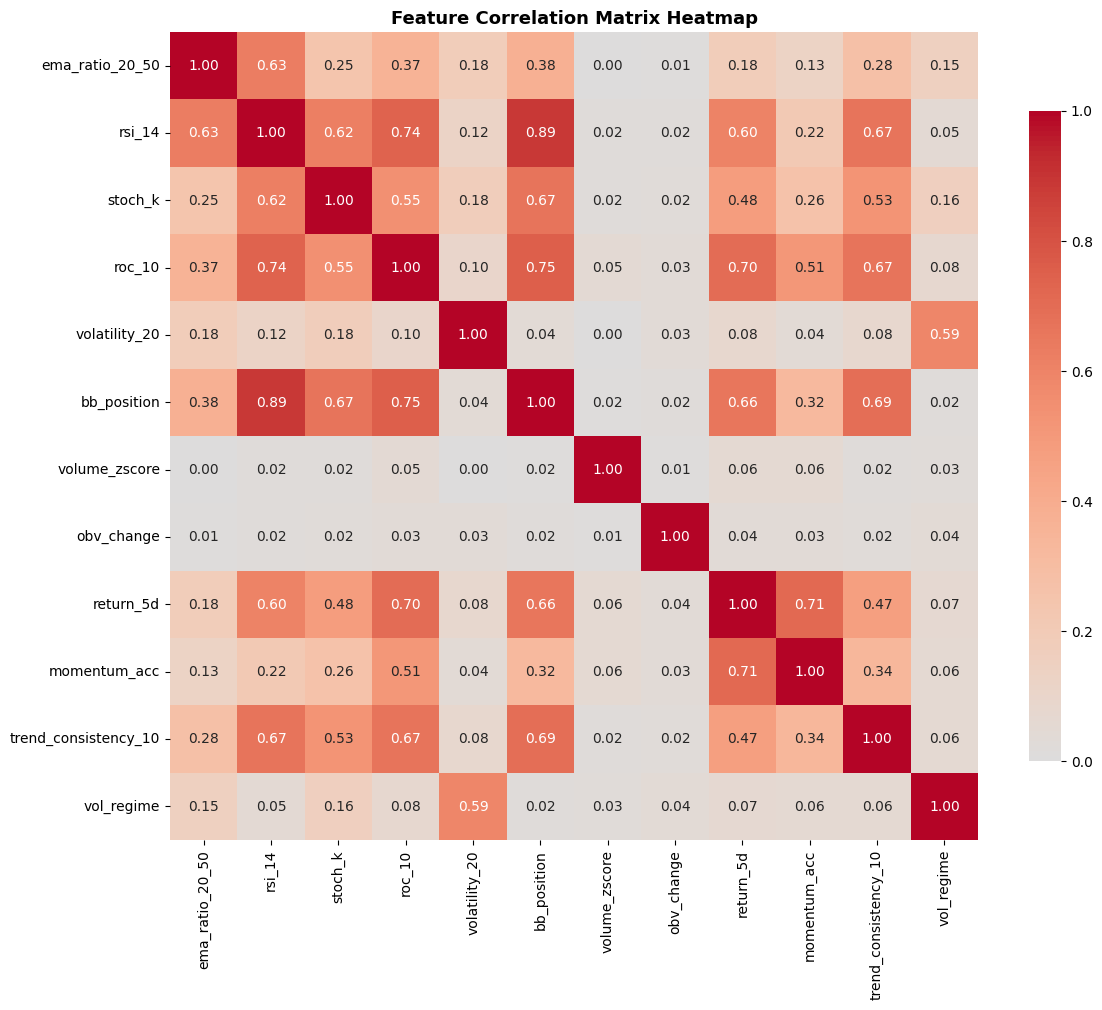

In [685]:
corr = X.corr().abs()
print(corr)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={"shrink": 0.8}, vmin=0, vmax=1)
plt.title("Feature Correlation Matrix Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [686]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,        # key difference
    stratify=y,          # keep class balance
    random_state=42
)


Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.46      0.43       488
           1       0.63      0.58      0.60       794

    accuracy                           0.53      1282
   macro avg       0.52      0.52      0.51      1282
weighted avg       0.54      0.53      0.54      1282

Confusion Matrix:
[[223 265]
 [336 458]]
Accuracy: 0.5312


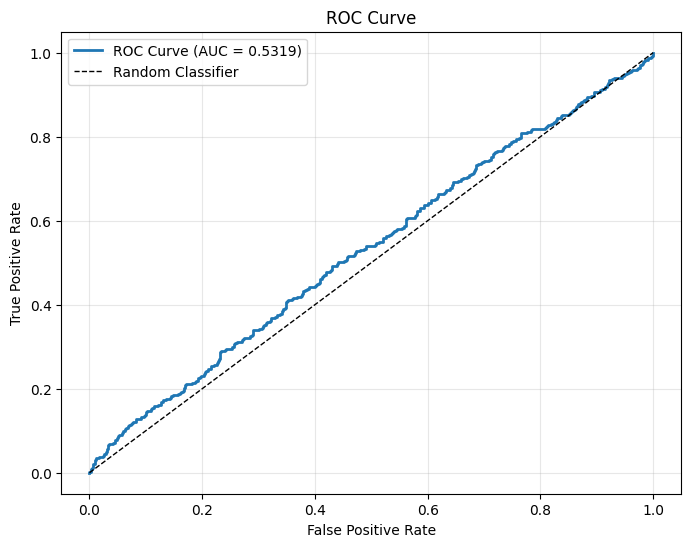

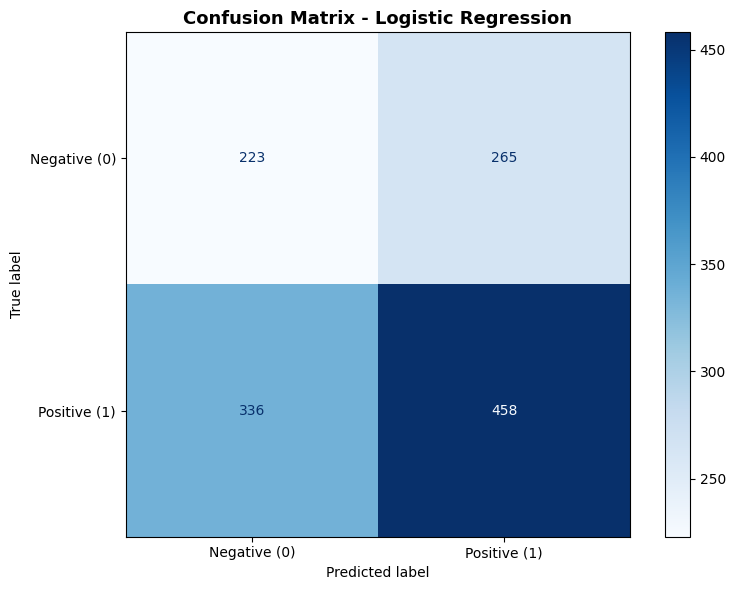


CONFUSION MATRIX BREAKDOWN
True Negatives (TN):  223  - Correctly predicted negative
False Positives (FP): 265  - Incorrectly predicted positive
False Negatives (FN): 336  - Incorrectly predicted negative
True Positives (TP):  458  - Correctly predicted positive

Sensitivity (Recall): 0.5768  - % of positives correctly identified
Specificity:          0.4570  - % of negatives correctly identified
Precision:            0.6335  - % of predicted positives that are correct


In [687]:
#FOR LOGISTIC REGRESSION
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.49).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))  
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}") 
# Add this:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ===== CONFUSION MATRIX VISUALIZATION =====

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative (0)', 'Positive (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix - Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print metrics
print("\n" + "=" * 70)
print("CONFUSION MATRIX BREAKDOWN")
print("=" * 70)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn}  - Correctly predicted negative")
print(f"False Positives (FP): {fp}  - Incorrectly predicted positive")
print(f"False Negatives (FN): {fn}  - Incorrectly predicted negative")
print(f"True Positives (TP):  {tp}  - Correctly predicted positive")
print(f"\nSensitivity (Recall): {tp / (tp + fn):.4f}  - % of positives correctly identified")
print(f"Specificity:          {tn / (tn + fp):.4f}  - % of negatives correctly identified")
print(f"Precision:            {tp / (tp + fp):.4f}  - % of predicted positives that are correct")

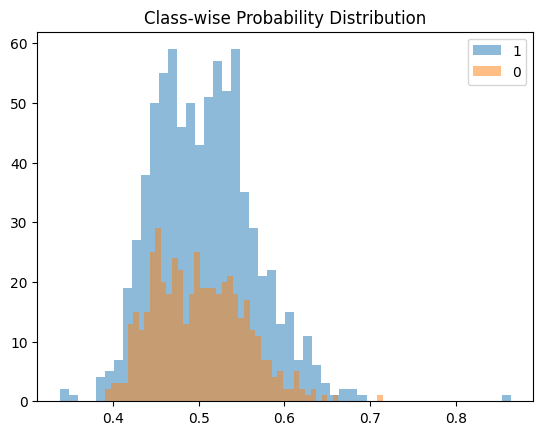

In [688]:
import matplotlib.pyplot as plt

plt.hist(y_prob[y_test==1], bins=50, alpha=0.5, label='1')
plt.hist(y_prob[y_test==0], bins=50, alpha=0.5, label='0')
plt.legend()
plt.title("Class-wise Probability Distribution")
plt.show()


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.57      0.68       488
           1       0.78      0.93      0.85       794

    accuracy                           0.79      1282
   macro avg       0.81      0.75      0.76      1282
weighted avg       0.80      0.79      0.78      1282

Random Forest Confusion Matrix:
[[277 211]
 [ 54 740]]
Random Forest Accuracy: 0.7933
Random Forest AUC: 0.8710


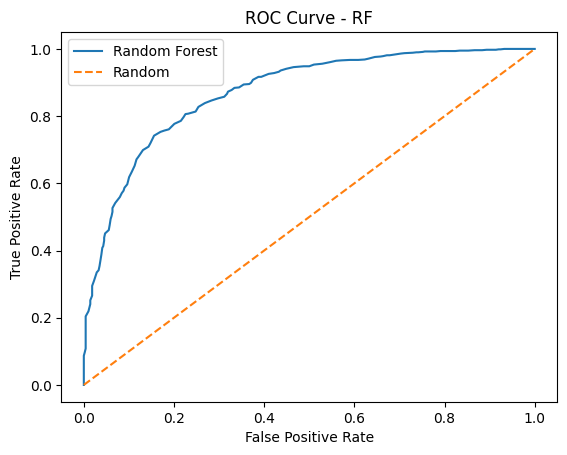

In [689]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)    
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], '--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - RF")
plt.legend()
plt.show()

In [693]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# ======================
# 1. TIME SPLIT (80/20)
# ======================
split = int(len(X) * 0.8)
X = df[selected_features]
y = df["target"]
print(y.value_counts())
print((X.index==y.index).all())
X_dev, X_test = X.iloc[:split], X.iloc[split:]
y_dev, y_test = y.iloc[:split], y.iloc[split:]

# ======================
# 2. RANDOM SPLIT (DEV)
# ======================
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.2, shuffle = True, stratify=y_dev, random_state=42)
# ======================
# 3. MODEL
# ======================
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# ======================
# 4. VALIDATION
# ======================
val_prob = model.predict_proba(X_val)[:, 1]
print("VAL AUC:", roc_auc_score(y_val, val_prob))

# ======================
# 5. FINAL TEST
# ======================
test_prob = model.predict_proba(X_test)[:, 1]
test_pred = model.predict(X_test)

print("TEST ACC:", accuracy_score(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_prob))

target
1    3968
0    2441
Name: count, dtype: int64
True
VAL AUC: 0.691343813851969
TEST ACC: 0.5514820592823713
TEST AUC: 0.5160661215881233
